# 🛒 Predicting E-commerce Cart Abandonment

Cart abandonment happens when a customer adds items to their cart but leaves the website without completing the purchase.  
In this project, we use **machine learning** 🤖 to analyze customer behavior and predict the likelihood of cart abandonment.

### 🎯 Project Goals
- 📊 Explore customer and session data  
- 🔍 Identify key factors influencing cart abandonment  
- 🧠 Build and evaluate predictive machine learning models  
- 💡 Provide insights to improve e-commerce conversion rates


In [8]:
import pandas as pd 
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [9]:
data = pd.read_csv("ecommerce_cart_abandonment_5k.csv")

In [3]:
data.head()

,UserID,SessionID,BrowserType,OperatingSystem,DeviceType,NumItemsInCart,CartTotalAmount,TimeSpentOnSiteMinutes,HasCouponApplied,IsReturningCustomer,LastPageViewedCategory,AbandonmentReason
0,8986,311935,Edge,MacOS,Tablet,2,87.96,7.39,False,True,Clothing,Found Better Price
1,1937,207006,Opera,MacOS,Desktop,1,120.00,11.37,False,False,Beauty,Payment Issues
2,3194,779500,Edge,iOS,Desktop,6,150.12,6.80,True,False,Electronics,Found Better Price
3,5125,980665,Opera,iOS,Mobile,3,88.20,7.52,True,True,Electronics,Distraction
4,7250,595333,Edge,Linux,Tablet,4,64.19,3.75,True,False,Books,High Shipping Cost


In [4]:
data.tail()

,UserID,SessionID,BrowserType,OperatingSystem,DeviceType,NumItemsInCart,CartTotalAmount,TimeSpentOnSiteMinutes,HasCouponApplied,IsReturningCustomer,LastPageViewedCategory,AbandonmentReason
4995,2553,895977,Edge,Linux,Desktop,3,116.70,11.37,True,True,Electronics,No Abandonment
4996,2761,651563,Chrome,Linux,Tablet,3,84.60,12.56,True,False,Toys,Payment Issues
4997,9775,834262,Safari,iOS,Desktop,3,26.17,4.42,False,False,Electronics,Payment Issues
4998,7799,240027,Safari,Linux,Tablet,1,76.07,7.90,True,False,Toys,High Shipping Cost
4999,5310,542826,Chrome,Android,Tablet,6,11.01,3.55,True,False,Toys,High Shipping Cost


In [5]:
data.describe()

,UserID,SessionID,NumItemsInCart,CartTotalAmount,TimeSpentOnSiteMinutes
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,5524.798000,546423.08360,3.015200,59.801418,8.089650
std,2600.325994,261066.96119,1.740912,42.437128,2.957523
min,1000.000000,100013.00000,0.000000,0.510000,0.000000
25%,3245.000000,317856.50000,2.000000,28.397500,6.130000
50%,5531.500000,546830.00000,3.000000,50.335000,8.090000
75%,7802.500000,771604.75000,4.000000,80.787500,10.120000
max,9998.000000,999978.00000,11.000000,338.770000,19.150000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UserID                  5000 non-null   int64  
 1   SessionID               5000 non-null   int64  
 2   BrowserType             5000 non-null   object 
 3   OperatingSystem         5000 non-null   object 
 4   DeviceType              5000 non-null   object 
 5   NumItemsInCart          5000 non-null   int64  
 6   CartTotalAmount         5000 non-null   float64
 7   TimeSpentOnSiteMinutes  5000 non-null   float64
 8   HasCouponApplied        5000 non-null   bool   
 9   IsReturningCustomer     5000 non-null   bool   
 10  LastPageViewedCategory  5000 non-null   object 
 11  AbandonmentReason       5000 non-null   object 
dtypes: bool(2), float64(2), int64(3), object(5)
memory usage: 400.5+ KB


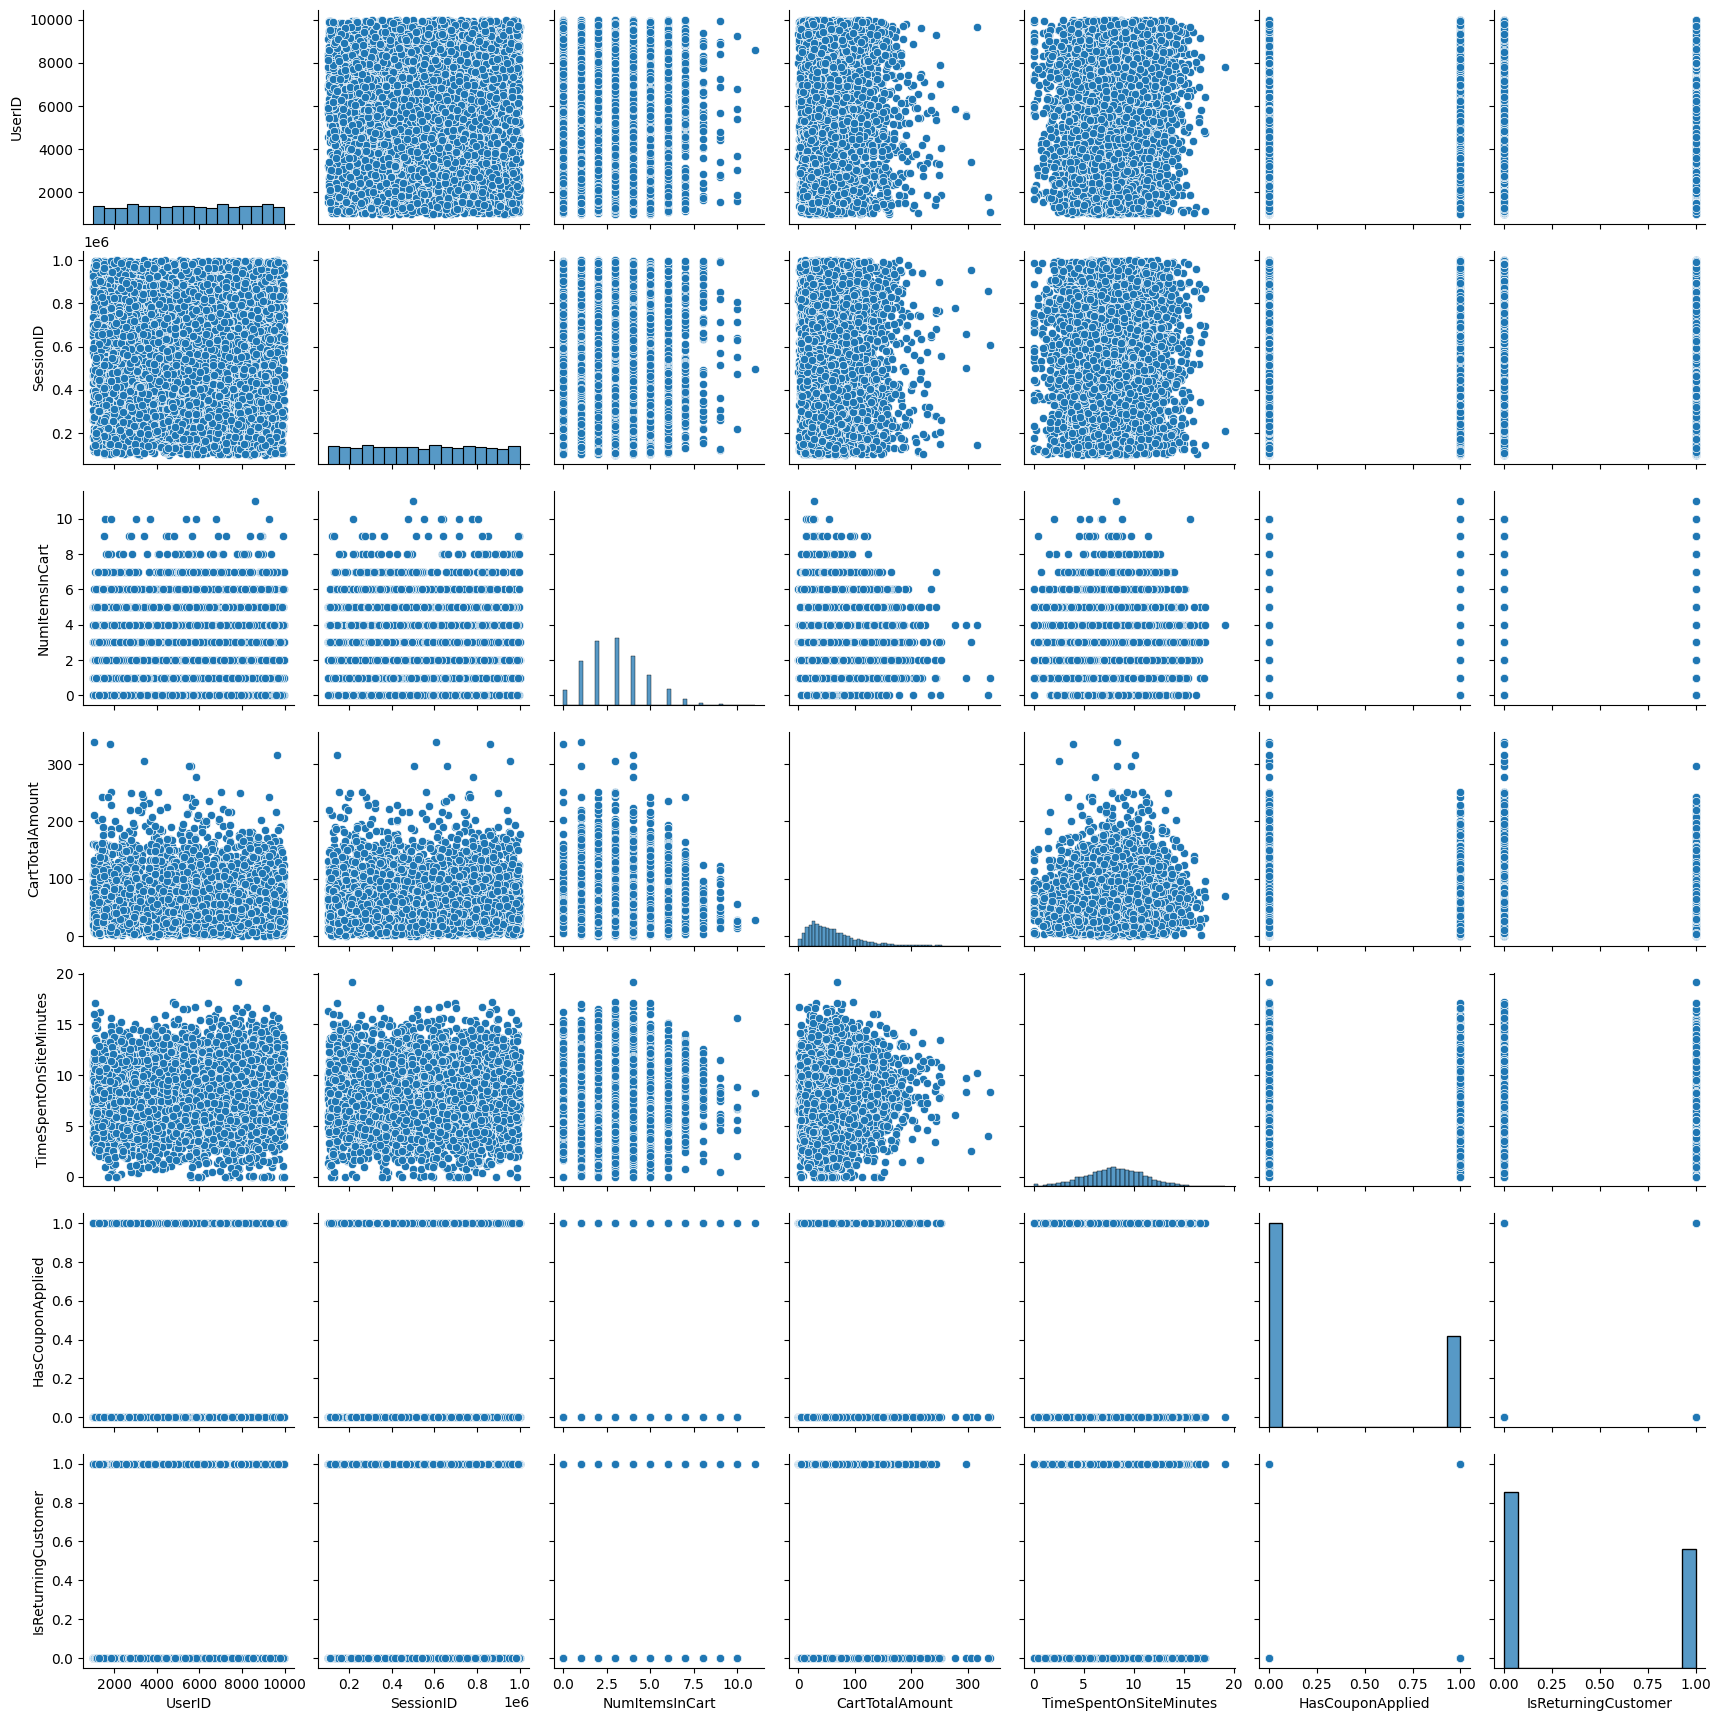

In [7]:
sns.pairplot(data)

### Machine Learning Predictions via RandomForest and DecisionTrees

In [14]:
# Creating a new column for cart abandonment (dependent variable)
new_col = 'Churn'

data[new_col] = data['AbandonmentReason'].apply(lambda x: 0 if x == 'No Abandonment' else 1)
